In [3]:
# Install required libraries if needed
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

# Set styles and random seed for reproducibility
sns.set_theme(style="darkgrid")
np.random.seed(42)

print("--- 1. GENERATING INVENTORY DATASET ---")
categories = ['Electronics', 'Accessories', 'Office Supplies', 'Hardware']
suppliers = ['TechCorp', 'SupplyCo', 'GlobalParts', 'ElectroMart']

# Create synthetic dataset
data = {
    'Product ID': [f'PRD-{i:03d}' for i in range(1, 151)],
    'Product Name': [f'Item_{i}' for i in range(1, 151)],
    'Category': [random.choice(categories) for _ in range(150)],
    'Quantity in Stock': np.random.randint(0, 250, 150),
    'Supplier': [random.choice(suppliers) for _ in range(150)],
    'Purchase Price': np.random.uniform(15, 600, 150).round(2),
    'Historical Sales': np.random.randint(40, 600, 150)
}

df = pd.DataFrame(data)

print("--- 2. DATA CLEANING & PREPROCESSING ---")
# Drop duplicates if any
df.drop_duplicates(inplace=True)

# Calculate Selling Price and Total Inventory Value
df['Selling Price'] = (df['Purchase Price'] * 1.3).round(2)
df['Total Inventory Value'] = (df['Quantity in Stock'] * df['Purchase Price']).round(2)

# Assign Stock Status dynamically
df['Stock Status'] = np.where(df['Quantity in Stock'] == 0, 'Out of Stock',
                     np.where(df['Quantity in Stock'] < 25, 'Low Stock', 'In Stock'))

print(f"Dataset successfully prepared with {len(df)} records.")
display(df.head())

--- 1. GENERATING INVENTORY DATASET ---
--- 2. DATA CLEANING & PREPROCESSING ---
Dataset successfully prepared with 150 records.


,Product ID,Product Name,Category,Quantity in Stock,Supplier,Purchase Price,Historical Sales,Selling Price,Total Inventory Value,Stock Status
0,PRD-001,Item_1,Accessories,102,SupplyCo,395.88,322,514.64,40379.76,In Stock
1,PRD-002,Item_2,Accessories,179,TechCorp,550.25,66,715.32,98494.75,In Stock
2,PRD-003,Item_3,Electronics,92,TechCorp,512.27,265,665.95,47128.84,In Stock
3,PRD-004,Item_4,Hardware,14,GlobalParts,277.93,316,361.31,3891.02,Low Stock
4,PRD-005,Item_5,Hardware,106,TechCorp,70.81,323,92.05,7505.86,In Stock


--- 3. INVENTORY DASHBOARD METRICS ---
Total Products: 150
Total Inventory Value: $5,856,422.83
Low Stock Items: 19
Out of Stock Items: 0

--- 4. VISUALIZATIONS ---


/tmp/ipykernel_1520/3622330032.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_stock, x='Category', y='Quantity in Stock', palette='viridis')


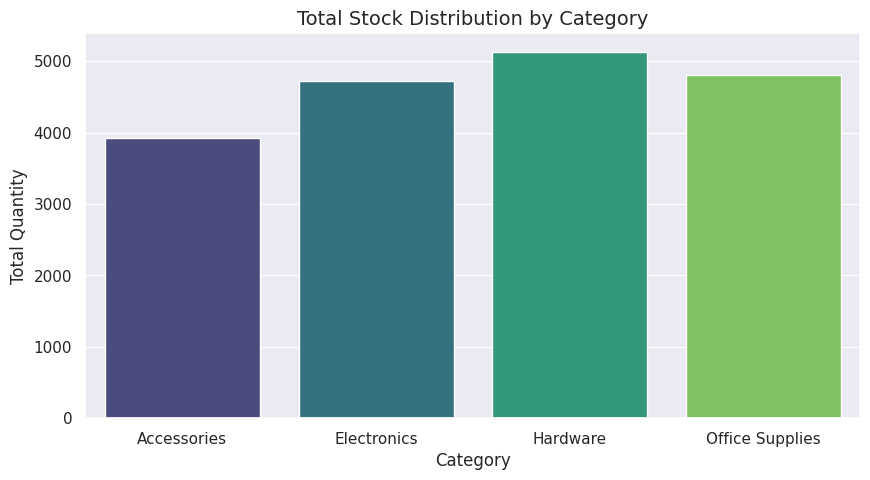

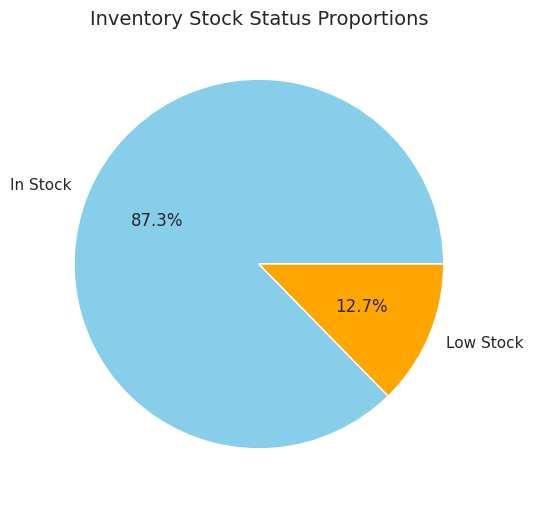

In [4]:
print("--- 3. INVENTORY DASHBOARD METRICS ---")
total_products = len(df)
total_value = df['Total Inventory Value'].sum()
low_stock_count = len(df[df['Stock Status'] == 'Low Stock'])
out_of_stock_count = len(df[df['Stock Status'] == 'Out of Stock'])

print(f"Total Products: {total_products}")
print(f"Total Inventory Value: ${total_value:,.2f}")
print(f"Low Stock Items: {low_stock_count}")
print(f"Out of Stock Items: {out_of_stock_count}")

print("\n--- 4. VISUALIZATIONS ---")
# Figure 1: Category-wise Stock Distribution
plt.figure(figsize=(10, 5))
cat_stock = df.groupby('Category')['Quantity in Stock'].sum().reset_index()
sns.barplot(data=cat_stock, x='Category', y='Quantity in Stock', palette='viridis')
plt.title("Total Stock Distribution by Category", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Total Quantity")
plt.show()

# Figure 2: Stock Status Proportions
plt.figure(figsize=(6, 6))
status_counts = df['Stock Status'].value_counts()
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', colors=['skyblue', 'orange', 'salmon'])
plt.title("Inventory Stock Status Proportions", fontsize=14)
plt.show()

In [5]:
print("--- 5. LOW STOCK ALERT SYSTEM ---")
alerts_df = df[df['Stock Status'].isin(['Low Stock', 'Out of Stock'])]
print(f"Items requiring attention: {len(alerts_df)}")
display(alerts_df[['Product ID', 'Product Name', 'Category', 'Quantity in Stock', 'Stock Status', 'Supplier']].head(10))

print("\n--- 6. SEARCH & FILTER EXAMPLE ---")
search_query = "Item_1"
filtered_results = df[(df['Product Name'].str.contains(search_query)) & (df['Category'] == 'Electronics')]
print(f"Search results for '{search_query}' in 'Electronics':")
display(filtered_results[['Product ID', 'Product Name', 'Quantity in Stock', 'Selling Price']])

--- 5. LOW STOCK ALERT SYSTEM ---
Items requiring attention: 19


,Product ID,Product Name,Category,Quantity in Stock,Stock Status,Supplier
3,PRD-004,Item_4,Hardware,14,Low Stock,GlobalParts
7,PRD-008,Item_8,Hardware,20,Low Stock,SupplyCo
22,PRD-023,Item_23,Accessories,1,Low Stock,ElectroMart
30,PRD-031,Item_31,Hardware,20,Low Stock,GlobalParts
34,PRD-035,Item_35,Hardware,21,Low Stock,ElectroMart
44,PRD-045,Item_45,Electronics,14,Low Stock,TechCorp
59,PRD-060,Item_60,Office Supplies,20,Low Stock,TechCorp
62,PRD-063,Item_63,Hardware,17,Low Stock,TechCorp
66,PRD-067,Item_67,Electronics,13,Low Stock,ElectroMart
69,PRD-070,Item_70,Office Supplies,8,Low Stock,GlobalParts



--- 6. SEARCH & FILTER EXAMPLE ---
Search results for 'Item_1' in 'Electronics':


,Product ID,Product Name,Quantity in Stock,Selling Price
12,PRD-013,Item_13,74,758.49
105,PRD-106,Item_106,47,548.64
126,PRD-127,Item_127,156,461.11
128,PRD-129,Item_129,44,734.47
129,PRD-130,Item_130,64,759.97
134,PRD-135,Item_135,128,775.79
135,PRD-136,Item_136,235,153.30
138,PRD-139,Item_139,62,155.49
141,PRD-142,Item_142,80,567.78
142,PRD-143,Item_143,135,253.79


In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

print("--- 7. DEMAND FORECASTING MODEL ---")

# Simulate next month's demand target variable
df['Next_Month_Demand'] = (df['Historical Sales'] * np.random.uniform(0.85, 1.25, len(df))).astype(int)

# Define features and target
features = ['Quantity in Stock', 'Purchase Price', 'Historical Sales']
X = df[features]
y = df['Next_Month_Demand']

# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
predictions = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"Model Training Complete!")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

--- 7. DEMAND FORECASTING MODEL ---
Model Training Complete!
Root Mean Squared Error (RMSE): 39.07
R² Score: 0.9434
